# Neuropathology anchoring of predicted risk

This notebook prints the secondary neuropathology anchoring table and recreates the grouped bar chart comparing clinical-only risk with medication-state risk. All outputs are saved under `op/neuro_anchor/` at the project root.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# -----------------------------------------------------------------------------
# Output path
# -----------------------------------------------------------------------------
# This notebook is intended to live in: project_root/notebooks/neuro_anchor.ipynb
# If it is run from the notebooks folder, project root is one level up.
# If it is run from project root, project root is the current working directory.

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

# Save all generated files into: project_root/op/5_neuro_anchor/
OUTPUT_DIR = PROJECT_ROOT / "op" / "5_neuro_anchor"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Current working directory: {cwd}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Saving results to: {OUTPUT_DIR}")


Current working directory: /home/ppanta/puru_proj/1_dementia_progress/dementia_progress_v0/notebooks
Project root: /home/ppanta/puru_proj/1_dementia_progress/dementia_progress_v0
Saving results to: /home/ppanta/puru_proj/1_dementia_progress/dementia_progress_v0/op/5_neuro_anchor


In [2]:
# -----------------------------------------------------------------------------
# Table 7. Secondary neuropathology anchoring of medication-state predicted risk
# -----------------------------------------------------------------------------

table7 = pd.DataFrame({
    "Outcome": [
        "High Alzheimer disease neuropathologic change",
        "High Braak stage",
        "Moderate/frequent neuritic plaques",
        "Lewy body pathology present",
        "Neuropathologic infarct present",
    ],
    "N": [711, 851, 851, 851, 711],
    "Outcome prevalence": [0.409, 0.461, 0.592, 0.337, 0.174],
    "Risk difference": [0.086, 0.075, 0.052, 0.032, -0.006],
    "Anchor AUROC": [0.615, 0.598, 0.568, 0.545, 0.492],
})

# Display manuscript-ready table.
display(Markdown("**Table 7. Secondary neuropathology anchoring of medication-state predicted risk**"))
display(table7)

# Save the table.
table7_path = OUTPUT_DIR / "table7_neuro_anchor_medication_state_risk.csv"
table7.to_csv(table7_path, index=False)

print(f"Saved table to: {table7_path}")


**Table 7. Secondary neuropathology anchoring of medication-state predicted risk**

,Outcome,N,Outcome prevalence,Risk difference,Anchor AUROC
0,High Alzheimer disease neuropathologic change,711,0.409,0.086,0.615
1,High Braak stage,851,0.461,0.075,0.598
2,Moderate/frequent neuritic plaques,851,0.592,0.052,0.568
3,Lewy body pathology present,851,0.337,0.032,0.545
4,Neuropathologic infarct present,711,0.174,-0.006,0.492


Saved table to: /home/ppanta/puru_proj/1_dementia_progress/dementia_progress_v0/op/5_neuro_anchor/table7_neuro_anchor_medication_state_risk.csv


In [3]:
display(Markdown(
    "**Note.** Neuropathology variables were not used as prediction features. "
    "These analyses were conducted only as secondary anchoring analyses to examine "
    "biological plausibility among participants with available neuropathology outcomes."
))


**Note.** Neuropathology variables were not used as prediction features. These analyses were conducted only as secondary anchoring analyses to examine biological plausibility among participants with available neuropathology outcomes.

In [4]:
# -----------------------------------------------------------------------------
# Plot values: neuropathology anchoring of clinical-only and medication-state risk
# -----------------------------------------------------------------------------
# These are the exact unrounded AUROC values used to recreate the grouped bar chart.

plot_df = pd.DataFrame({
    "Outcome": [
        "High ADNC",
        "High Braak",
        "Moderate/frequent\nneuritic plaques",
        "Lewy body\npathology",
        "Infarct",
    ],
    "Clinical-only risk": [0.584782, 0.571479, 0.545309, 0.535946, 0.493062],
    "Medication-state risk": [0.614597, 0.598100, 0.568135, 0.544882, 0.491812],
})

display(Markdown("**Plot values used for the neuropathology anchoring figure**"))
display(plot_df)

plot_values_path = OUTPUT_DIR / "fig_neuro_anchor_plot_values.csv"
plot_df.to_csv(plot_values_path, index=False)

print(f"Saved plot values to: {plot_values_path}")


**Plot values used for the neuropathology anchoring figure**

,Outcome,Clinical-only risk,Medication-state risk
0,High ADNC,0.584782,0.614597
1,High Braak,0.571479,0.598100
2,Moderate/frequent\nneuritic plaques,0.545309,0.568135
3,Lewy body\npathology,0.535946,0.544882
4,Infarct,0.493062,0.491812


Saved plot values to: /home/ppanta/puru_proj/1_dementia_progress/dementia_progress_v0/op/5_neuro_anchor/fig_neuro_anchor_plot_values.csv


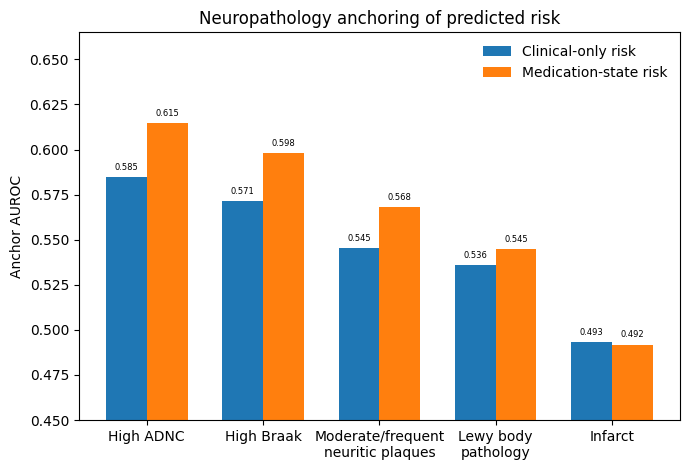

Saved figure PNG to: /home/ppanta/puru_proj/1_dementia_progress/dementia_progress_v0/op/5_neuro_anchor/fig_neuro_anchor_predicted_risk.png
Saved figure PDF to: /home/ppanta/puru_proj/1_dementia_progress/dementia_progress_v0/op/5_neuro_anchor/fig_neuro_anchor_predicted_risk.pdf


In [5]:
# -----------------------------------------------------------------------------
# Figure. Neuropathology anchoring of predicted risk
# -----------------------------------------------------------------------------

x = np.arange(len(plot_df))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4.8))

bars1 = ax.bar(
    x - width / 2,
    plot_df["Clinical-only risk"],
    width,
    label="Clinical-only risk"
)

bars2 = ax.bar(
    x + width / 2,
    plot_df["Medication-state risk"],
    width,
    label="Medication-state risk"
)

ax.set_title("Neuropathology anchoring of predicted risk")
ax.set_ylabel("Anchor AUROC")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["Outcome"])
ax.set_ylim(0.45, 0.665)
ax.legend(loc="upper right", frameon=False)

# Add values on top of each bar.
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.003,
            f"{h:.3f}",
            ha="center",
            va="bottom",
            fontsize=6
        )

fig.tight_layout()

figure_png_path = OUTPUT_DIR / "fig_neuro_anchor_predicted_risk.png"
figure_pdf_path = OUTPUT_DIR / "fig_neuro_anchor_predicted_risk.pdf"

fig.savefig(figure_png_path, dpi=300, bbox_inches="tight")
fig.savefig(figure_pdf_path, bbox_inches="tight")

plt.show()

print(f"Saved figure PNG to: {figure_png_path}")
print(f"Saved figure PDF to: {figure_pdf_path}")

In [6]:
# -----------------------------------------------------------------------------
# Quick output check
# -----------------------------------------------------------------------------

for path in sorted(OUTPUT_DIR.iterdir()):
    print(path.relative_to(PROJECT_ROOT))


op/5_neuro_anchor/fig_neuro_anchor_plot_values.csv
op/5_neuro_anchor/fig_neuro_anchor_predicted_risk.pdf
op/5_neuro_anchor/fig_neuro_anchor_predicted_risk.png
op/5_neuro_anchor/table7_neuro_anchor_medication_state_risk.csv
